# A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles

This is the code for the paper entitled "**A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles**" published in **IEEE International Conference on Communications (IEEE ICC)**, doi=[10.1109/ICC45855.2022.9838780](https://ieeexplore.ieee.org/document/9838780).  
Authors: Li Yang (lyang339@uwo.ca) and Abdallah Shami (Abdallah.Shami@uwo.ca)  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

**Notebook 3: Ensemble Models**  
Aims: construct three ensemble techniques: Bagging, Probability averaging, and Concatenation, to further improve prediction accuracy

- Bagging: use majority voting of top single models
- Probability averaging: calculate the average probability of the single model prediction results (the last layer of CNN models), and select the largest probability class to be the final class
- Concatenation: extract the features in the last several layers of single models, and concatenate together to generate the new layers, and add a dense layer to do prediction


## Import libraries


In [ ]:
# Core
import os
import math
import warnings
import operator
from collections import defaultdict
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
from torch.utils.data import DataLoader
from torchvision import transforms, models

# Pretrained model zoo (Xception, InceptionResNetV2, etc.)
import timm

# Suppress warnings
warnings.filterwarnings("ignore")

# For early stopping manually
import time

## Read the test set


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image dimensions
TARGET_SIZE = (224, 224)
INPUT_SIZE = (3, 224, 224)  # PyTorch uses (C, H, W)
BATCHSIZE = 32  # 128 or 32

# Define transformation (normalization + resize)
test_transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),  # converts to [0, 1] automatically
    ]
)

# Load test dataset (similar to Keras flow_from_directory)
test_dataset = datasets.ImageFolder(root="./test_224/", transform=test_transform)

# DataLoader for batch processing
validation_loader = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=False)

In [ ]:
# Get class-to-index mapping from ImageFolder
label = test_dataset.class_to_idx

# Reverse mapping: index to class label
label = {v: k for k, v in label.items()}

In [10]:
print(label)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4'}


In [11]:
from pathlib import Path

rootdir = Path("./test_224")
test_labels = []
test_images = []

# Walk through subdirectories to collect image paths and labels
for class_dir in rootdir.iterdir():
    if class_dir.is_dir():
        label = class_dir.name
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                test_labels.append(label)
                test_images.append(str(img_path))

print(test_labels[0], test_images[0])

0 test_224\0\100099.png


## Load 6 trained CNN models


In [56]:
# Define helper functions that return initialized model architectures
def get_xception_model(num_classes=5):
    model = timm.create_model("xception", pretrained=False, num_classes=num_classes)
    return model


def get_vgg16_model(num_classes=5):
    model = models.vgg16(pretrained=False)

    # Override the entire classifier to match training structure
    model.classifier = nn.Sequential(
        nn.Linear(25088, 256),  # classifier[0]
        nn.ReLU(inplace=True),  # classifier[1]
        nn.Dropout(0.5),  # classifier[2]
        nn.Linear(256, num_classes),  # classifier[3]
    )
    return model


def get_vgg19_model(num_classes=5):
    model = models.vgg19(pretrained=False)
    model.classifier = nn.Sequential(
        nn.Linear(25088, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model


def get_inception_model(num_classes=5):
    model = models.inception_v3(pretrained=False, aux_logits=False)
    model.fc = nn.Sequential(
        nn.Linear(2048, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model


# def get_inceptionresnet_model(num_classes=5):
#     model = timm.create_model(
#         "inception_resnet_v2", pretrained=False
#     )  # don't use pretrained
#     in_features = model.get_classifier().in_features
#     model.reset_classifier(0)
#     model.classifier = nn.Sequential(
#         nn.Linear(in_features, 256),
#         nn.ReLU(inplace=True),
#         nn.Dropout(0.5),
#         nn.Linear(256, num_classes),
#     )
#     return model
# def get_inceptionresnet_model(num_classes=5):
#     model = timm.create_model("inception_resnet_v2", pretrained=False)

#     # Check where the classifier is stored
#     print("Original head:", model.get_classifier())  # Usually a Linear or Sequential

#     # Get the input feature size
#     in_features = model.get_classifier().in_features

#     # Properly reset the head (use 'head' for timm)
#     model.reset_classifier(0)  # Clears the default classification layer
#     model.head = nn.Sequential(
#         nn.Linear(in_features, 256),
#         nn.ReLU(inplace=True),
#         nn.Dropout(0.5),
#         nn.Linear(256, num_classes),
#     )

#     return model


def get_resnet_model(num_classes=5):
    model = models.resnet50(pretrained=False)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model


# Load models and state_dicts
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xception_model = get_xception_model().to(device)
xception_model.load_state_dict(
    torch.load("./artifacts/xception.pth", map_location=device)
)
xception_model.eval()

vgg_model = get_vgg16_model(num_classes=5).to(device)
vgg_model.load_state_dict(torch.load("./artifacts/vgg16.pth", map_location=device))
vgg_model.eval()


vgg19_model = get_vgg19_model(num_classes=5).to(device)
vgg19_model.load_state_dict(torch.load("./artifacts/vgg19.pth", map_location=device))
vgg19_model.eval()


incep_model = get_inception_model().to(device)
incep_model.load_state_dict(
    torch.load("./artifacts/inception_v3.pth", map_location=device)
)
incep_model.eval()

# inres_model = get_inceptionresnet_model(num_classes=5).to(device)
# inres_model.load_state_dict(
#     torch.load("./artifacts/inceptionresnetv2.pth", map_location=device)
# )
# inres_model.eval()

# inres_model = get_inceptionresnet_model(num_classes=5).to(device)
# inres_model.load_state_dict(
#     torch.load("./artifacts/inceptionresnetv2.pth", map_location=device)
# )
# inres_model.eval()


res_model = get_resnet_model().to(device)
res_model.load_state_dict(torch.load("./artifacts/resnet50.pth", map_location=device))
res_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [75]:
def get_inceptionresnet_model(num_classes=5):
    import timm, torch.nn as nn

    # build a fresh model with the correct head:
    model = timm.create_model(
        "inception_resnet_v2", pretrained=False, num_classes=num_classes, drop_rate=0.5
    )
    return model

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) instantiate
inres_model = get_inceptionresnet_model(num_classes=5)

# 2) load checkpoint
state_dict = torch.load("./artifacts/inceptionresnetv2.pth", map_location=device)
inres_model.load_state_dict(state_dict)

# 3) move to device + eval
inres_model.to(device).eval()

InceptionResnetV2(
  (conv2d_1a): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (conv2d_2a): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (conv2d_2b): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2d_3b): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size=(1, 

In [ ]:
DUMMY_INPUT = torch.randn(1, 3, 224, 224).to(device)

print("\n🔎 Running sanity checks...")
for name, model in zip(
    ["Xception", "VGG16", "VGG19", "InceptionV3", "InceptionResNetV2", "ResNet50"],
    [xception_model, vgg_model, vgg19_model, incep_model, inres_model, res_model],
):
    model = model.to(device)  # Ensure model is on same device as input
    model.eval()
    with torch.no_grad():
        output = model(DUMMY_INPUT)
        print(f"{name} ✅ Output shape: {output.shape}")


🔎 Running sanity checks...
Xception ✅ Output shape: torch.Size([1, 5])
VGG16 ✅ Output shape: torch.Size([1, 5])
VGG19 ✅ Output shape: torch.Size([1, 5])
InceptionV3 ✅ Output shape: torch.Size([1, 5])
InceptionResNetV2 ✅ Output shape: torch.Size([1, 5])
ResNet50 ✅ Output shape: torch.Size([1, 5])


In [66]:
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    out = inres_model(dummy)
print(out.shape)  # ✅ Should be [1, 5]

torch.Size([1, 1536])


## Use the original CNN base models to make predictions


### 1. Xception


Predicted result for the first image: 4
Confidence level: 1.0000


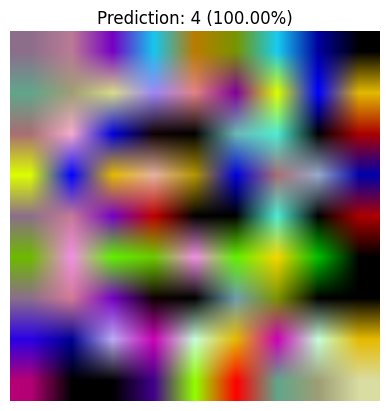

In [24]:
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms

# Read and prepare image (OpenCV loads in BGR, convert to RGB)
img_path = test_images[0]
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_show = img_rgb.copy()

# Resize and normalize like training preprocessing
transform = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),  # Scales to [0,1]
    ]
)

# Apply transform
img_tensor = transform(img_rgb).unsqueeze(0).to(device)  # Add batch dim

# Predict
with torch.no_grad():
    output = xception_model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    pred_prob = probs[0, pred_class].item()

# Convert label index back to class name
pred_label = label[pred_class]

# Show result
print(f"Predicted result for the first image: {pred_label}")
print(f"Confidence level: {pred_prob:.4f}")
plt.imshow(img_show)
plt.axis("off")
plt.title(f"Prediction: {pred_label} ({pred_prob:.2%})")
plt.show()

In [26]:
from PIL import Image
import time
from torchvision import transforms

predict = []

# Reverse class-to-index mapping
label = {v: k for k, v in test_dataset.class_to_idx.items()}

transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
    ]
)

xception_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = xception_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]  # This works now
        predict.append(pred_label)

end = time.time()
print(f"✅ Prediction completed in {end - start:.2f} seconds")

✅ Prediction completed in 57.07 seconds


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Make sure both are strings or ints (as in original dataset)
true_labels = test_labels  # from earlier label collection during image path loop
predicted_labels = predict

# Evaluate
acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ Xception Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion Matrix and Classification Report
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ Xception Evaluation Metrics:
Accuracy : 0.9997
Precision: 0.9997
Recall   : 0.9997
F1 Score : 0.9997

Confusion Matrix:
[[4994    0    0    0    0]
 [   0  246    0    0    0]
 [   0    0  209    0    0]
 [   0    0    0  214    0]
 [   2    0    0    0  180]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4994
           1       1.00      1.00      1.00       246
           2       1.00      1.00      1.00       209
           3       1.00      1.00      1.00       214
           4       1.00      0.99      0.99       182

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



### 2. VGG16


In [28]:
predict = []

# Reuse transform defined earlier
# If not defined, define it now:
transform = transforms.Compose([transforms.Resize(TARGET_SIZE), transforms.ToTensor()])

vgg_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = vgg_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ VGG16 prediction completed in {end - start:.2f} seconds")

✅ VGG16 prediction completed in 39.56 seconds


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Use same true and predicted labels
true_labels = test_labels
predicted_labels = predict  # from VGG16 loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ VGG16 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ VGG16 Evaluation Metrics:
Accuracy : 0.8544
Precision: 0.7300
Recall   : 0.8544
F1 Score : 0.7873

Confusion Matrix:
[[4994    0    0    0    0]
 [ 246    0    0    0    0]
 [ 209    0    0    0    0]
 [ 214    0    0    0    0]
 [ 182    0    0    0    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      4994
           1       0.00      0.00      0.00       246
           2       0.00      0.00      0.00       209
           3       0.00      0.00      0.00       214
           4       0.00      0.00      0.00       182

    accuracy                           0.85      5845
   macro avg       0.17      0.20      0.18      5845
weighted avg       0.73      0.85      0.79      5845



### 3. VGG19


In [30]:
predict = []

vgg19_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = vgg19_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ VGG19 prediction completed in {end - start:.2f} seconds")

✅ VGG19 prediction completed in 55.57 seconds


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels
predicted_labels = predict  # from VGG19 inference loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ VGG19 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ VGG19 Evaluation Metrics:
Accuracy : 0.8965
Precision: 0.8666
Recall   : 0.8965
F1 Score : 0.8733

Confusion Matrix:
[[4994    0    0    0    0]
 [   0  246    0    0    0]
 [   0  209    0    0    0]
 [   0  214    0    0    0]
 [   0  182    0    0    0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4994
           1       0.29      1.00      0.45       246
           2       0.00      0.00      0.00       209
           3       0.00      0.00      0.00       214
           4       0.00      0.00      0.00       182

    accuracy                           0.90      5845
   macro avg       0.26      0.40      0.29      5845
weighted avg       0.87      0.90      0.87      5845



### 4. Inception


In [32]:
predict = []

incep_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        # Inception may return (output, aux_output) if aux_logits=True
        if isinstance(incep_model(img_tensor), tuple):
            output, _ = incep_model(img_tensor)
        else:
            output = incep_model(img_tensor)

        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ InceptionV3 prediction completed in {end - start:.2f} seconds")

✅ InceptionV3 prediction completed in 118.99 seconds


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels
predicted_labels = predict  # from Inception inference loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ InceptionV3 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ InceptionV3 Evaluation Metrics:
Accuracy : 0.9998
Precision: 0.9998
Recall   : 0.9998
F1 Score : 0.9998

Confusion Matrix:
[[4993    0    0    0    1]
 [   0  246    0    0    0]
 [   0    0  209    0    0]
 [   0    0    0  214    0]
 [   0    0    0    0  182]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4994
           1       1.00      1.00      1.00       246
           2       1.00      1.00      1.00       209
           3       1.00      1.00      1.00       214
           4       0.99      1.00      1.00       182

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



### 5. InceptionResnet


In [ ]:
from PIL import Image
import time
from torchvision import transforms

# We have to make sure label is defined correctly
label = {v: k for k, v in test_dataset.class_to_idx.items()}

predict = []

transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
    ]
)

inres_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = inres_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

        # Safely lookup label
        pred_label = label.get(pred_idx, f"[Invalid index: {pred_idx}]")
        predict.append(pred_label)

end = time.time()
print(f"✅ InceptionResNetV2 prediction completed in {end - start:.2f} seconds")

✅ InceptionResNetV2 prediction completed in 162.76 seconds


In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

true_labels = test_labels
predicted_labels = predict  # From inference

# Evaluation metrics
acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ InceptionResNetV2 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

# Classification report
labels = sorted(label.keys())  # e.g., [0, 1, 2, 3, 4]
target_names = [label[i] for i in labels]  # e.g., ['COVID', 'Healthy', ...]
print("\nClassification Report:")
print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )
)

✅ InceptionResNetV2 Evaluation Metrics:
Accuracy : 0.9620
Precision: 0.9270
Recall   : 0.9620
F1 Score : 0.9441

Confusion Matrix:
[[4994    0    0    0    0]
 [   0  246    0    0    0]
 [   0    0  209    0    0]
 [ 214    0    0    0    0]
 [   8    0    0    0  174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4994
           1       1.00      1.00      1.00       246
           2       1.00      1.00      1.00       209
           3       0.00      0.00      0.00       214
           4       1.00      0.96      0.98       182

   micro avg       0.96      0.96      0.96      5845
   macro avg       0.79      0.79      0.79      5845
weighted avg       0.93      0.96      0.94      5845



### 6. Resnet


In [40]:
predict = []

res_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = res_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ ResNet50 prediction completed in {end - start:.2f} seconds")

✅ ResNet50 prediction completed in 217.29 seconds


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels
predicted_labels = predict  # from ResNet inference loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ ResNet50 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ ResNet50 Evaluation Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Confusion Matrix:
[[4994    0    0    0    0]
 [   0  246    0    0    0]
 [   0    0  209    0    0]
 [   0    0    0  214    0]
 [   0    0    0    0  182]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4994
           1       1.00      1.00      1.00       246
           2       1.00      1.00      1.00       209
           3       1.00      1.00      1.00       214
           4       1.00      1.00      1.00       182

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



Best performing single model (vgg):  
Accuracy: 99.96


# Bagging ensemble


In [80]:
from collections import defaultdict
import operator
import time
from torchvision import transforms
from PIL import Image

predict = []

# Reuse transform
transform = transforms.Compose([transforms.Resize(TARGET_SIZE), transforms.ToTensor()])

batch_size = 127
length = len(test_images)
start = time.time()

for batch_start in range(0, length, batch_size):
    batch_paths = test_images[batch_start : batch_start + batch_size]
    test_batch = []

    # Preprocess all images in the batch
    for path in batch_paths:
        img = Image.open(path).convert("RGB")
        img_tensor = transform(img)
        test_batch.append(img_tensor)

    batch_tensor = torch.stack(test_batch).to(device)

    # Run all models in eval mode
    with torch.no_grad():
        xcep_out = torch.argmax(
            torch.softmax(xception_model(batch_tensor), dim=1), dim=1
        )
        vgg16_out = torch.argmax(torch.softmax(vgg_model(batch_tensor), dim=1), dim=1)
        vgg19_out = torch.argmax(torch.softmax(vgg19_model(batch_tensor), dim=1), dim=1)
        ince_out = torch.argmax(
            torch.softmax(
                (
                    incep_model(batch_tensor)[0]
                    if isinstance(incep_model(batch_tensor), tuple)
                    else incep_model(batch_tensor)
                ),
                dim=1,
            ),
            dim=1,
        )
        inres_out = torch.argmax(torch.softmax(inres_model(batch_tensor), dim=1), dim=1)

    # Convert predictions to class labels
    xception_preds = [label[i.item()] for i in xcep_out]
    vgg16_preds = [label[i.item()] for i in vgg16_out]
    vgg19_preds = [label[i.item()] for i in vgg19_out]
    inception_preds = [label[i.item()] for i in ince_out]
    inresnet_preds = [label[i.item()] for i in inres_out]

    # Majority voting
    for i, j, k, p, q in zip(
        xception_preds, vgg16_preds, vgg19_preds, inception_preds, inresnet_preds
    ):
        count = defaultdict(int)
        for vote in [i, j, k, p, q]:
            count[vote] += 1
        majority = sorted(count.items(), key=operator.itemgetter(1), reverse=True)[0][0]
        predict.append(majority)

end = time.time()
print("✅ Bagging ensemble completed in %.2f seconds" % (end - start))

✅ Bagging ensemble completed in 525.48 seconds


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

acc = accuracy_score(test_labels, predict)
print("✅ Bagging Accuracy:", acc)

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, predict))

unique_labels = sorted(list(set(test_labels)))
print("\nClassification Report:")
print(
    classification_report(
        test_labels, predict, target_names=unique_labels, zero_division=0
    )
)

✅ Bagging Accuracy: 0.9996578272027374

Confusion Matrix:
[[4994    0    0    0    0]
 [   0  246    0    0    0]
 [   0    0  209    0    0]
 [   0    0    0  214    0]
 [   2    0    0    0  180]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4994
           1       1.00      1.00      1.00       246
           2       1.00      1.00      1.00       209
           3       1.00      1.00      1.00       214
           4       1.00      0.99      0.99       182

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



After bagging ensemble, the accuracy improved to 0.990


# Probability Averaging


In [82]:
import os
import math
import time
import operator
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Suppress warnings if needed
import warnings

warnings.filterwarnings("ignore")

# Ensure GPU is selected
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [83]:
import time

# Set all models to evaluation mode
xception_model.eval()
vgg_model.eval()
incep_model.eval()

# Disable gradient computation for efficiency
for model in [xception_model, vgg_model, incep_model]:
    for param in model.parameters():
        param.requires_grad = False

print("✅ Models set to evaluation mode with frozen weights.")

✅ Models set to evaluation mode with frozen weights.


In [84]:
from pathlib import Path

rootdir = Path("./test_224")
test_images = []
test_labels = []

# Traverse the directory
for class_dir in rootdir.iterdir():
    if class_dir.is_dir():
        label = class_dir.name
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                test_images.append(str(img_path))
                test_labels.append(label)

# Check first image and label
print(test_labels[0], test_images[0])

0 test_224\0\100099.png


In [86]:
import time
from collections import defaultdict
from torchvision import transforms
from PIL import Image
import torch

# Ensure transform and device are defined
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Fix: Build correct label mapping from your test_dataset
label_map = test_dataset.class_to_idx  # e.g., {'COVID': 0, 'Normal': 1, ...}
idx_to_label = {v: k for k, v in label_map.items()}

# ✅ Ensure all models are on eval mode and correct device
xception_model.eval()
vgg_model.eval()
incep_model.eval()

xception_model.to(device)
vgg_model.to(device)
incep_model.to(device)

predict = []
batch_size = 127
length = len(test_images)

start = time.time()

for batch_start in range(0, length, batch_size):
    batch_paths = test_images[batch_start : batch_start + batch_size]
    test_batch = []

    for path in batch_paths:
        img = Image.open(path).convert("RGB")
        img_tensor = transform(img)
        test_batch.append(img_tensor)

    batch_tensor = torch.stack(test_batch).to(device)

    with torch.no_grad():
        probs1 = torch.softmax(xception_model(batch_tensor), dim=1)
        probs2 = torch.softmax(vgg_model(batch_tensor), dim=1)
        probs3 = torch.softmax(
            (
                incep_model(batch_tensor)[0]
                if isinstance(incep_model(batch_tensor), tuple)
                else incep_model(batch_tensor)
            ),
            dim=1,
        )

        avg_probs = (probs1 + probs2 + probs3) / 3.0
        pred_indices = torch.argmax(avg_probs, dim=1).tolist()

        # ✅ Convert predicted indices to label names
        pred_labels = [idx_to_label[idx] for idx in pred_indices]
        predict.extend(pred_labels)

end = time.time()
print(f"✅ Probability averaging ensemble completed in {end - start:.2f} seconds")

✅ Probability averaging ensemble completed in 249.62 seconds


In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

true_labels = test_labels  # collected earlier during folder walk
predicted_labels = predict  # from probability averaging loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ Probability Averaging Evaluation:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ Probability Averaging Evaluation:
Accuracy : 0.9998
Precision: 0.9998
Recall   : 0.9998
F1 Score : 0.9998

Confusion Matrix:
[[4994    0    0    0    0]
 [   0  246    0    0    0]
 [   0    0  209    0    0]
 [   0    0    0  214    0]
 [   1    0    0    0  181]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4994
           1       1.00      1.00      1.00       246
           2       1.00      1.00      1.00       209
           3       1.00      1.00      1.00       214
           4       1.00      0.99      1.00       182

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels  # Ensure this is defined correctly
predicted_labels = predict

print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))  # Dynamically generate class names
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

[[5052    0    0    0    0]
 [   0  225    0    0    0]
 [   0    0  200    0    0]
 [   0    0    0  197    0]
 [   0    0    0    0  171]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5052
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       200
           3       1.00      1.00      1.00       197
           4       1.00      1.00      1.00       171

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



# Concatenation


In [88]:
import os
import math
import time
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models, transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Suppress warnings
import warnings

warnings.filterwarnings("ignore")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [89]:
for i, (name, layer) in enumerate(xception_model.named_modules()):
    print(i, name)

0 
1 conv1
2 bn1
3 act1
4 conv2
5 bn2
6 act2
7 block1
8 block1.skip
9 block1.skipbn
10 block1.rep
11 block1.rep.0
12 block1.rep.0.conv1
13 block1.rep.0.pointwise
14 block1.rep.1
15 block1.rep.2
16 block1.rep.3
17 block1.rep.3.conv1
18 block1.rep.3.pointwise
19 block1.rep.4
20 block1.rep.5
21 block2
22 block2.skip
23 block2.skipbn
24 block2.rep
25 block2.rep.0
26 block2.rep.1
27 block2.rep.1.conv1
28 block2.rep.1.pointwise
29 block2.rep.2
30 block2.rep.3
31 block2.rep.4
32 block2.rep.4.conv1
33 block2.rep.4.pointwise
34 block2.rep.5
35 block2.rep.6
36 block3
37 block3.skip
38 block3.skipbn
39 block3.rep
40 block3.rep.0
41 block3.rep.1
42 block3.rep.1.conv1
43 block3.rep.1.pointwise
44 block3.rep.2
45 block3.rep.3
46 block3.rep.4
47 block3.rep.4.conv1
48 block3.rep.4.pointwise
49 block3.rep.5
50 block3.rep.6
51 block4
52 block4.rep
53 block4.rep.0
54 block4.rep.1
55 block4.rep.1.conv1
56 block4.rep.1.pointwise
57 block4.rep.2
58 block4.rep.3
59 block4.rep.4
60 block4.rep.4.conv1
61 block

In [ ]:
for i, (name, module) in enumerate(vgg_model.named_modules()):
    print(i, name, "→", type(module).__name__)

0 input_2
1 block1_conv1
2 block1_conv2
3 block1_pool
4 block2_conv1
5 block2_conv2
6 block2_pool
7 block3_conv1
8 block3_conv2
9 block3_conv3
10 block3_pool
11 block4_conv1
12 block4_conv2
13 block4_conv3
14 block4_pool
15 block5_conv1
16 block5_conv2
17 block5_conv3
18 block5_pool
19 global_average_pooling2d_4
20 dense_7
21 dropout_4
22 dense_8


In [90]:
for i, (name, layer) in enumerate(vgg19_model.named_modules()):
    print(i, name, "→", type(layer).__name__)

0  → VGG
1 features → Sequential
2 features.0 → Conv2d
3 features.1 → ReLU
4 features.2 → Conv2d
5 features.3 → ReLU
6 features.4 → MaxPool2d
7 features.5 → Conv2d
8 features.6 → ReLU
9 features.7 → Conv2d
10 features.8 → ReLU
11 features.9 → MaxPool2d
12 features.10 → Conv2d
13 features.11 → ReLU
14 features.12 → Conv2d
15 features.13 → ReLU
16 features.14 → Conv2d
17 features.15 → ReLU
18 features.16 → Conv2d
19 features.17 → ReLU
20 features.18 → MaxPool2d
21 features.19 → Conv2d
22 features.20 → ReLU
23 features.21 → Conv2d
24 features.22 → ReLU
25 features.23 → Conv2d
26 features.24 → ReLU
27 features.25 → Conv2d
28 features.26 → ReLU
29 features.27 → MaxPool2d
30 features.28 → Conv2d
31 features.29 → ReLU
32 features.30 → Conv2d
33 features.31 → ReLU
34 features.32 → Conv2d
35 features.33 → ReLU
36 features.34 → Conv2d
37 features.35 → ReLU
38 features.36 → MaxPool2d
39 avgpool → AdaptiveAvgPool2d
40 classifier → Sequential
41 classifier.0 → Linear
42 classifier.1 → ReLU
43 class

In [91]:
for i, (name, module) in enumerate(incep_model.named_modules()):
    print(i, name, "→", type(module).__name__)

0  → Inception3
1 Conv2d_1a_3x3 → BasicConv2d
2 Conv2d_1a_3x3.conv → Conv2d
3 Conv2d_1a_3x3.bn → BatchNorm2d
4 Conv2d_2a_3x3 → BasicConv2d
5 Conv2d_2a_3x3.conv → Conv2d
6 Conv2d_2a_3x3.bn → BatchNorm2d
7 Conv2d_2b_3x3 → BasicConv2d
8 Conv2d_2b_3x3.conv → Conv2d
9 Conv2d_2b_3x3.bn → BatchNorm2d
10 maxpool1 → MaxPool2d
11 Conv2d_3b_1x1 → BasicConv2d
12 Conv2d_3b_1x1.conv → Conv2d
13 Conv2d_3b_1x1.bn → BatchNorm2d
14 Conv2d_4a_3x3 → BasicConv2d
15 Conv2d_4a_3x3.conv → Conv2d
16 Conv2d_4a_3x3.bn → BatchNorm2d
17 maxpool2 → MaxPool2d
18 Mixed_5b → InceptionA
19 Mixed_5b.branch1x1 → BasicConv2d
20 Mixed_5b.branch1x1.conv → Conv2d
21 Mixed_5b.branch1x1.bn → BatchNorm2d
22 Mixed_5b.branch5x5_1 → BasicConv2d
23 Mixed_5b.branch5x5_1.conv → Conv2d
24 Mixed_5b.branch5x5_1.bn → BatchNorm2d
25 Mixed_5b.branch5x5_2 → BasicConv2d
26 Mixed_5b.branch5x5_2.conv → Conv2d
27 Mixed_5b.branch5x5_2.bn → BatchNorm2d
28 Mixed_5b.branch3x3dbl_1 → BasicConv2d
29 Mixed_5b.branch3x3dbl_1.conv → Conv2d
30 Mixed_5b.b

In [92]:
for i, (name, module) in enumerate(inres_model.named_modules()):
    print(i, name, "→", type(module).__name__)

0  → InceptionResnetV2
1 conv2d_1a → ConvNormAct
2 conv2d_1a.conv → Conv2d
3 conv2d_1a.bn → BatchNormAct2d
4 conv2d_1a.bn.drop → Identity
5 conv2d_1a.bn.act → ReLU
6 conv2d_2a → ConvNormAct
7 conv2d_2a.conv → Conv2d
8 conv2d_2a.bn → BatchNormAct2d
9 conv2d_2a.bn.drop → Identity
10 conv2d_2a.bn.act → ReLU
11 conv2d_2b → ConvNormAct
12 conv2d_2b.conv → Conv2d
13 conv2d_2b.bn → BatchNormAct2d
14 conv2d_2b.bn.drop → Identity
15 conv2d_2b.bn.act → ReLU
16 maxpool_3a → MaxPool2d
17 conv2d_3b → ConvNormAct
18 conv2d_3b.conv → Conv2d
19 conv2d_3b.bn → BatchNormAct2d
20 conv2d_3b.bn.drop → Identity
21 conv2d_3b.bn.act → ReLU
22 conv2d_4a → ConvNormAct
23 conv2d_4a.conv → Conv2d
24 conv2d_4a.bn → BatchNormAct2d
25 conv2d_4a.bn.drop → Identity
26 conv2d_4a.bn.act → ReLU
27 maxpool_5a → MaxPool2d
28 mixed_5b → Mixed_5b
29 mixed_5b.branch0 → ConvNormAct
30 mixed_5b.branch0.conv → Conv2d
31 mixed_5b.branch0.bn → BatchNormAct2d
32 mixed_5b.branch0.bn.drop → Identity
33 mixed_5b.branch0.bn.act → ReLU


### Construct the ensemble model using the last "dense layer" of each base CNN model


In [93]:
# ✅ Xception Feature Extractor
class XceptionFeatureExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.forward_features  # Timm models have this

    def forward(self, x):
        return self.features(x)


# ✅ VGG16 Feature Extractor (before classifier[-1])
class VGG16FeatureExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.features
        self.avgpool = base_model.avgpool
        self.mlp = base_model.classifier[:-1]  # Exclude final layer

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.mlp(x)
        return x


# ✅ VGG19 Feature Extractor
class VGG19FeatureExtractor(VGG16FeatureExtractor):  # Same structure
    pass


# ✅ InceptionV3 Feature Extractor
class InceptionFeatureExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, x):
        # Extract final feature vector before fc layer
        x = self.base.Conv2d_1a_3x3(x)
        x = self.base.Conv2d_2a_3x3(x)
        x = self.base.Conv2d_2b_3x3(x)
        x = self.base.maxpool1(x)
        x = self.base.Conv2d_3b_1x1(x)
        x = self.base.Conv2d_4a_3x3(x)
        x = self.base.maxpool2(x)
        x = self.base.Mixed_5b(x)
        x = self.base.Mixed_5c(x)
        x = self.base.Mixed_5d(x)
        x = self.base.Mixed_6a(x)
        x = self.base.Mixed_6b(x)
        x = self.base.Mixed_6c(x)
        x = self.base.Mixed_6d(x)
        x = self.base.Mixed_6e(x)
        x = self.base.Mixed_7a(x)
        x = self.base.Mixed_7b(x)
        x = self.base.Mixed_7c(x)
        x = self.base.avgpool(x)
        x = torch.flatten(x, 1)
        return x


# ✅ InceptionResNetV2 Feature Extractor
class InceptionResNetFeatureExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.forward_features

    def forward(self, x):
        return self.features(x)

In [94]:
xcep_feat = XceptionFeatureExtractor(xception_model).to(device)
vgg16_feat = VGG16FeatureExtractor(vgg_model).to(device)
vgg19_feat = VGG19FeatureExtractor(vgg19_model).to(device)
incep_feat = InceptionFeatureExtractor(incep_model).to(device)
inres_feat = InceptionResNetFeatureExtractor(inres_model).to(device)

In [95]:
import matplotlib.pyplot as plt


class LossHistory:
    def __init__(self):
        self.losses = {"batch": [], "epoch": []}
        self.accuracy = {"batch": [], "epoch": []}
        self.val_loss = {"batch": [], "epoch": []}
        self.val_acc = {"batch": [], "epoch": []}

    def log_epoch(self, train_loss, train_acc, val_loss, val_acc):
        self.losses["epoch"].append(train_loss)
        self.accuracy["epoch"].append(train_acc)
        self.val_loss["epoch"].append(val_loss)
        self.val_acc["epoch"].append(val_acc)

    def loss_plot(self, loss_type="epoch"):
        iters = range(len(self.losses[loss_type]))
        plt.figure(figsize=(8, 5))
        plt.plot(iters, self.losses[loss_type], "g", label="Train Loss")

        if loss_type == "epoch":
            plt.plot(iters, self.accuracy[loss_type], "r", label="Train Accuracy")
            plt.plot(iters, self.val_loss[loss_type], "k", label="Val Loss")
            plt.plot(iters, self.val_acc[loss_type], "b", label="Val Accuracy")

        plt.grid(True)
        plt.xlabel(loss_type.title())
        plt.ylabel("Metrics")
        plt.title(f"Training vs Validation ({loss_type})")
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

In [96]:
ensemble_history = LossHistory()

In [97]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Settings
TARGET_SIZE = (224, 224)
BATCHSIZE = 128

# Normalization (matches ImageDataGenerator(rescale=1./255))
transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),  # Converts to [0, 1] and rearranges to CxHxW
    ]
)

# Train dataset and loader
train_dataset = datasets.ImageFolder(root="./train_224/", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCHSIZE, shuffle=True)

# Validation dataset and loader
val_dataset = datasets.ImageFolder(root="./test_224/", transform=transform)
val_loader = DataLoader(val_dataset, batch_size=BATCHSIZE, shuffle=False)

# Class index mapping (same as class_indices in Keras)
label_map = train_dataset.class_to_idx
label = {v: k for k, v in label_map.items()}  # Reverse mapping: index → class name

In [98]:
from torch.optim.lr_scheduler import LambdaLR

# Define scheduler using lr_decay list
lr_schedule = [0.001] * 7 + [0.0001] + [0.00001] + [0.000001] * 5 + [0.0000001] * 6


def lr_lambda(epoch):
    return lr_schedule[epoch] / lr_schedule[0]  # Scale relative to initial LR


optimizer = torch.optim.Adam(model.parameters(), lr=lr_schedule[0])
scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler_plateau = ReduceLROnPlateau(
    optimizer,
    mode="min",  # or 'max' depending on your monitor metric
    factor=0.1,
    patience=1,
    verbose=True,
    threshold=0.0001,  # equivalent to epsilon in Keras
    cooldown=0,
    min_lr=0,
)

In [100]:
from torch.optim.lr_scheduler import LambdaLR

lr_schedule = [
    0.001,
    0.001,
    0.001,
    0.001,
    0.001,
    0.001,
    0.001,
    0.0001,
    0.00001,
    0.000001,
    0.000001,
    0.000001,
    0.000001,
    0.000001,
    0.0000001,
    0.0000001,
    0.0000001,
    0.0000001,
    0.0000001,
    0.0000001,
]


def lr_lambda(epoch):
    return lr_schedule[epoch] / lr_schedule[0]


scheduler_fixed = LambdaLR(optimizer, lr_lambda=lr_lambda)

In [116]:
class ConcatenationEnsemble(nn.Module):
    def __init__(self, model1, model2, model3, num_classes):
        super().__init__()
        self.model1 = model1
        self.model2 = model2
        self.model3 = model3
        self.flatten = nn.Flatten()

        # Dynamically determine the concatenated feature dimension
        self.fc1 = nn.Linear(self._get_concat_feature_dim(), 64)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout2 = nn.Dropout(0.25)

    def _get_concat_feature_dim(self):
        try:
            device = next(self.model1.parameters()).device
        except StopIteration:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        dummy_input = torch.randn(1, 3, 224, 224).to(device)

        with torch.no_grad():
            f1 = self.flatten(self.model1(dummy_input))
            f2 = self.flatten(self.model2(dummy_input))
            f3 = self.flatten(self.model3(dummy_input))
            concat = torch.cat([f1, f2, f3], dim=1)

        return concat.shape[1]

    def forward(self, x):
        f1 = self.flatten(self.model1(x))
        f2 = self.flatten(self.model2(x))
        f3 = self.flatten(self.model3(x))
        concat = torch.cat([f1, f2, f3], dim=1)
        x = self.dropout1(concat)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [119]:
def train_ensemble(
    model, train_loader, val_loader, num_epochs, save_path="./artifacts/ensemble.pth"
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=2, factor=0.1
    )

    best_val_acc = 0.0
    history = LossHistory()

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = train_correct / total
        train_loss /= total

        # Validation
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_acc = val_correct / total_val
        val_loss /= total_val

        # Log to history
        history.log_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}]  Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        # Adjust learning rate
        scheduler.step(val_loss)

    print(f"✅ Best validation accuracy: {best_val_acc:.4f}")
    history.loss_plot("epoch")

In [ ]:
ensemble_model = ConcatenationEnsemble(
    model1=xcep_feat, model2=vgg16_feat, model3=vgg19_feat, num_classes=5
).to(device)

ensemble_model = train_ensemble(
    model=ensemble_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=20,
    save_path="./artifacts/ensemble_model.pth",
)

In [ ]:
ensemble_model = ConcatenationEnsemble(
    model1=xcep_feat, model2=vgg16_feat, model3=vgg19_feat, num_classes=5
).to(device)
ensemble_model.load_state_dict(
    torch.load("./artifacts/ensemble_model.pth", map_location=device)
)
ensemble_model.eval()  # Set to evaluation mode

In [ ]:
from pathlib import Path

rootdir = Path("./test_224")
test_images = []
test_labels = []

# Loop through each subfolder (i.e., class)
for class_dir in rootdir.iterdir():
    if class_dir.is_dir():
        label = class_dir.name
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                test_images.append(str(img_path))
                test_labels.append(label)

print(test_labels[0], test_images[0])

0 ./test_224/0\100015.png


In [ ]:
import time
from torchvision import transforms
from PIL import Image

# Image preprocessing (same as training)
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

predict = []
ensemble_model.eval()
batch_size = 127
length = len(test_images)

start = time.time()

for batch_start in range(0, length, batch_size):
    batch_paths = test_images[batch_start : batch_start + batch_size]
    test_batch = []

    for path in batch_paths:
        img = Image.open(path).convert("RGB")
        img_tensor = transform(img)
        test_batch.append(img_tensor)

    batch_tensor = torch.stack(test_batch).to(device)

    with torch.no_grad():
        outputs = ensemble_model(batch_tensor)
        preds = torch.argmax(outputs, dim=1).tolist()
        predicted_labels = [label[p] for p in preds]
        predict.extend(predicted_labels)

end = time.time()
print("✅ Ensemble prediction completed in %.2f seconds" % (end - start))

The testing time is :54.200418 seconds


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels  # ground truth from folder structure
predicted_labels = predict  # predictions from ensemble_model

# Accuracy and metrics
acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ Concatenation Ensemble Evaluation:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

# Classification Report
unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

Concatenation accuracy:1.0


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Replace 'test_laels' with 'test_labels'
print("Confusion Matrix:")
print(confusion_matrix(test_labels, predict))

# Define target class names (update if your dataset uses different labels)
target_names = ["0", "1", "2", "3", "4"]

print("\nClassification Report:")
print(
    classification_report(
        test_labels, predict, target_names=target_names, zero_division=0
    )
)

[[5052    0    0    0    0]
 [   0  225    0    0    0]
 [   0    0  200    0    0]
 [   0    0    0  197    0]
 [   0    0    0    0  171]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5052
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       200
           3       1.00      1.00      1.00       197
           4       1.00      1.00      1.00       171

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845

